In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=8a506cda5023111425c53c87407745efcdf396be363cac4d5850ec17050657c2
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
# Simple LIME Example for Classification
# Import Libraries
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from lime.lime_tabular import LimeTabularExplainer

In [ ]:
# 1. Load Dataset
iris = load_iris()
X = iris.data
y = iris.target

In [ ]:
# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 3. Train Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
# 4. Predictions & Accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
# 5. Create LIME Explainer
explainer = LimeTabularExplainer(
    X_train,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    mode='classification'
)

In [ ]:
# 6. Explain One Prediction
sample = X_test[0]
explanation = explainer.explain_instance(
    sample,
    model.predict_proba
)

In [ ]:
# 7. Show Prediction
prediction = model.predict([sample])[0]
print("\nPredicted Class:")
print(iris.target_names[prediction])


Predicted Class:
versicolor


In [ ]:
# 8. Print Feature Importance
print("\nLIME Explanation:\n")
for feature, weight in explanation.as_list():
    print(feature, ":", round(weight, 4))


LIME Explanation:

4.25 < petal length (cm) <= 5.10 : 0.2114
0.30 < petal width (cm) <= 1.30 : 0.1774
sepal width (cm) <= 2.80 : -0.0222
5.75 < sepal length (cm) <= 6.40 : 0.003


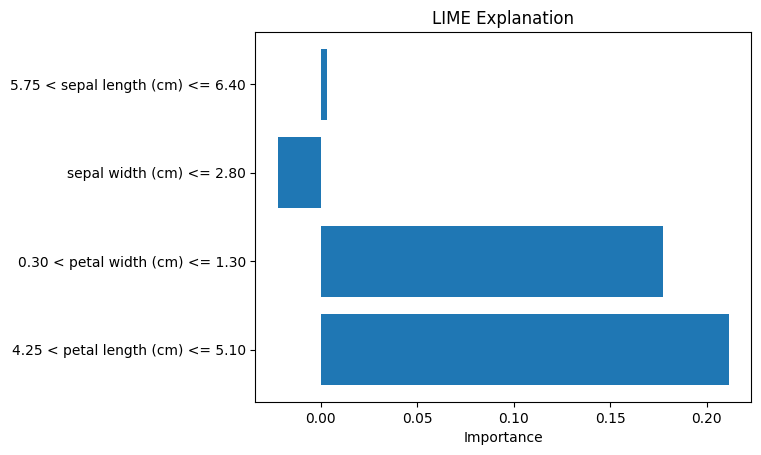

In [ ]:
# 9. Visualization
features = []
weights = []

for feature, weight in explanation.as_list():
    features.append(feature)
    weights.append(weight)

plt.barh(features, weights)
plt.xlabel("Importance")
plt.title("LIME Explanation")
plt.show()